In [106]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [107]:
df = pd.read_csv('insurance_encoded.csv')

In [108]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520


In [109]:
## Independent and dependent Features

x = df.iloc[: , : -1]
y = df.iloc[:,-1]

In [110]:
## train test split
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.25 , random_state=42)

In [111]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((1003, 6), (335, 6), (1003,), (335,))

In [112]:
## Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Text(0.5, 1.0, 'x_train After Scaling')

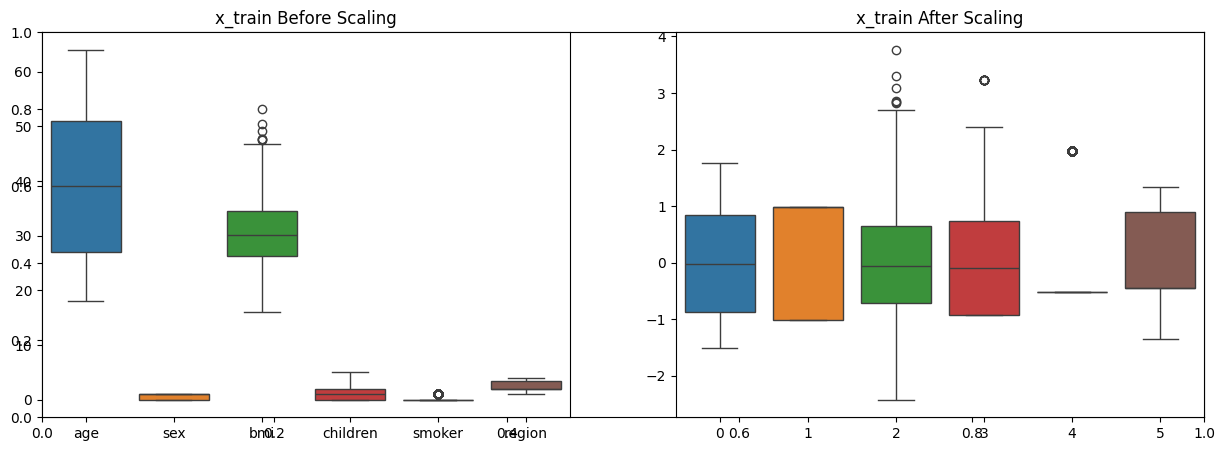

In [113]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('x_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train After Scaling')

#### Linear Regression

In [114]:
## Linear Model 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

linreg = LinearRegression()
linreg.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[3646.54, 24.07,2025.76, 514.75,9543.06, 333.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.327e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[34.9 ,32.75,32.43,30.98,30.26,28.28]"


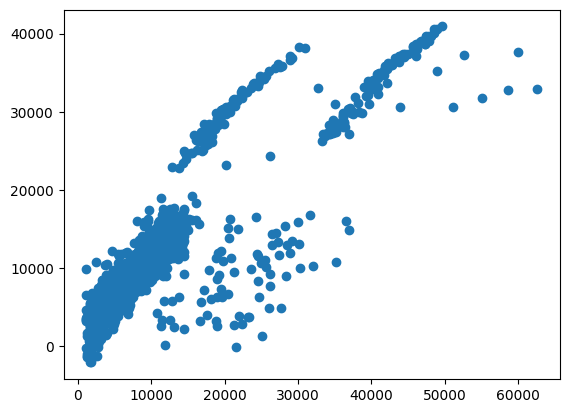

In [115]:
plt.scatter(y_train , linreg.predict(x_train_scaled))

In [137]:
y_pred = linreg.predict(x_test_scaled)
new_data = pd.DataFrame([[19,0,27.900,0,1,1]])

new_data_scaler = scaler.transform(new_data)
linreg.predict(new_data_scaler)

/Users/dhruvitjalodhara/programming/ML Practice/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([24949.70273683])

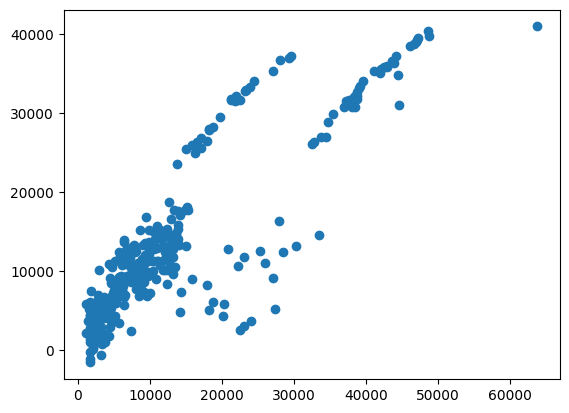

In [117]:
plt.scatter(y_test , y_pred)

In [118]:
from math import sqrt


mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = sqrt(mse)
score = r2_score(y_test,y_pred)

print("Mean Absolute Error : " , mae)
print("Mean Squared Error : " , mse)
print("Root Mean Squared Error : " , rmse)
print("R2 Score : " , score)

Mean Absolute Error :  4252.856455792367
Mean Squared Error :  35174149.32705306
Root Mean Squared Error :  5930.779824530081
R2 Score :  0.7668905583460908


In [119]:
# Adjusted R2 

1-(1-score)*(len(y_test)-1)/(len(y_test) - x_test.shape[1]-1)

0.7626263612426656

#### Ridge Regression

In [120]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from math import sqrt

ridge = Ridge()
ridge.fit(x_train_scaled,y_train)

y_pred = ridge.predict(x_test_scaled)

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = sqrt(mse)
score = r2_score(y_test,y_pred)

print("Mean Absolute Error : " , mae)
print("Mean Squared Error : " , mse)
print("Root Mean Squared Error : " , rmse)
print("R2 Score : " , score)

Mean Absolute Error :  4254.268228889468
Mean Squared Error :  35178920.115647174
Root Mean Squared Error :  5931.182016735549
R2 Score :  0.766858940925721


In [121]:
# Adjusted R2 

1-(1-score)*(len(y_test)-1)/(len(y_test) - x_test.shape[1]-1)

0.76259416545485

#### Lasso Regression

In [122]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from math import sqrt

lasso = Lasso()
lasso.fit(x_train_scaled,y_train)

y_pred = lasso.predict(x_test_scaled)

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = sqrt(mse)
score = r2_score(y_test,y_pred)

print("Mean Absolute Error : " , mae)
print("Mean Squared Error : " , mse)
print("Root Mean Squared Error : " , rmse)
print("R2 Score : " , score)

Mean Absolute Error :  4252.70083470549
Mean Squared Error :  35174460.19720336
Root Mean Squared Error :  5930.806032674089
R2 Score :  0.7668884981180952


In [123]:
# Adjusted R2 

1-(1-score)*(len(y_test)-1)/(len(y_test) - x_test.shape[1]-1)

0.7626242633275726

#### Elastic Net Regression

In [124]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from math import sqrt

elastic = ElasticNet()
elastic.fit(x_train_scaled,y_train)

y_pred = elastic.predict(x_test_scaled)

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = sqrt(mse)
score = r2_score(y_test,y_pred)

print("Mean Absolute Error : " , mae)
print("Mean Squared Error : " , mse)
print("Root Mean Squared Error : " , rmse)
print("R2 Score : " , score)

Mean Absolute Error :  5239.538787533339
Mean Squared Error :  49160087.40106062
Root Mean Squared Error :  7011.425489945723
R2 Score :  0.6742016297490165


In [125]:
# Adjusted R2 

1-(1-score)*(len(y_test)-1)/(len(y_test) - x_test.shape[1]-1)

0.6682419034639375

In [126]:
#### Assumptions

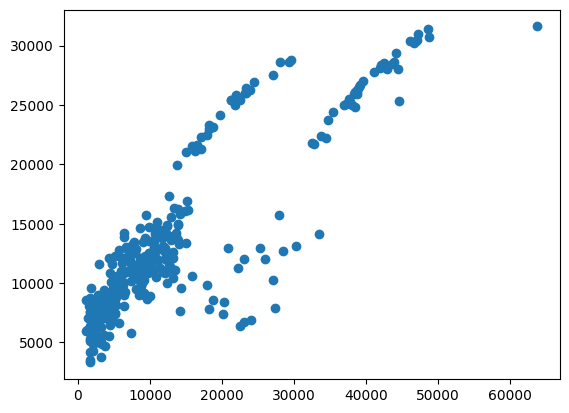

In [127]:
plt.scatter(y_test,y_pred)

In [128]:
residuals = y_test - y_pred
print(residuals)

764     -1096.542196
887     -3643.705195
890       709.660357
1293    -1672.600963
259     11370.400093
            ...     
342       640.000848
308     -2273.745291
1128     4795.648574
503     10708.860776
1197    -5012.694675
Name: charges, Length: 335, dtype: float64


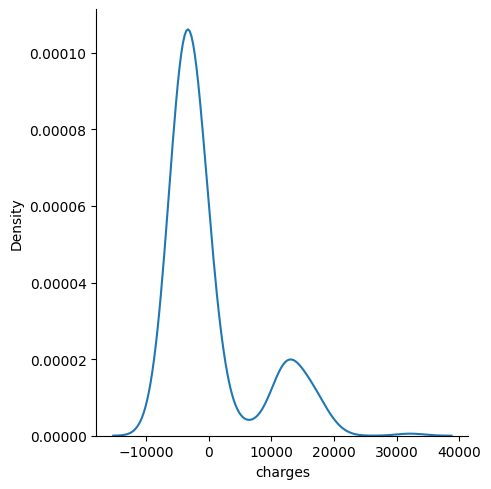

In [129]:
## plot this plot

sns.displot(residuals ,kind='kde')

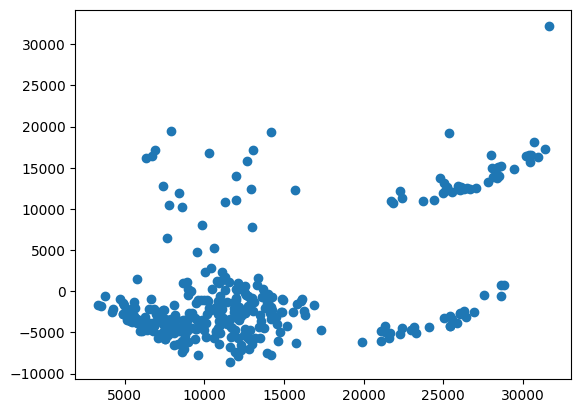

In [130]:
## scatter plot wrt predictions and residuals 
plt.scatter(y_pred,residuals)

#### Pickling the model

In [131]:
import pickle

pickle.dump(scaler , open('/Users/dhruvitjalodhara/programming/ML Practice/Insurance Premium Predictor/Models/scaler.pkl' , 'wb'))
pickle.dump(linreg , open('/Users/dhruvitjalodhara/programming/ML Practice/Insurance Premium Predictor/Models/linear.pkl' , 'wb'))